# CoChebyshev 1D XY model: Direct_Truncate bond-dimension comparison

This notebook compares the spectra obtained with `cheb_ttns_Direct_Truncate` for several SVD bond dimensions.  For each bond dimension, the direct Chebyshev TTNS basis is built with `N=250`, then the effective CoChebyshev recurrence is evaluated with `N_r=500`.


In [1]:
import copy
import importlib
import sys
import time
from fractions import Fraction
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

CHEBYSHEV_DIR = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
if str(CHEBYSHEV_DIR) not in sys.path:
    sys.path.insert(0, str(CHEBYSHEV_DIR))

from pytreenet.core import Node
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.operators import Hamiltonian, TensorProduct
from pytreenet.operators.models.two_site_model import XYModel
from pytreenet.operators.common_operators import pauli_matrices
from pytreenet.ttns.ttns_ttno.application import ApplicationMethod, apply_ttno_to_ttns
from pytreenet.util import SVDParameters

import CheTTNS as chettns_utils
chettns_utils = importlib.reload(chettns_utils)


## Helper functions


In [2]:
def random_complex(shape, rng, scale=1.0):
    return scale * (rng.normal(size=shape) + 1j * rng.normal(size=shape))


def build_open_chain_ttns(n_sites, bond_dim, phys_dim=2, seed=20260717):
    """Build a random open-chain TTNS/MPS geometry compatible with XYModel."""
    rng = np.random.default_rng(seed)
    ttns = TreeTensorNetworkState()

    root_node = Node(identifier="0")
    root_tensor = random_complex((bond_dim, phys_dim), rng)
    ttns.add_root(root_node, root_tensor)

    parent = "0"
    for i in range(1, n_sites):
        node_id = str(i)
        node = Node(identifier=node_id)
        if i == n_sites - 1:
            tensor = random_complex((bond_dim, phys_dim), rng)
        else:
            tensor = random_complex((bond_dim, bond_dim, phys_dim), rng)

        parent_leg = 0 if parent == "0" else 1
        ttns.add_child_to_parent(node, tensor, 0, parent, parent_leg)
        parent = node_id

    ttns.normalize()
    return ttns


def create_sz_operator(site_ids, k=None):
    """Create S_k^z = sqrt(2/(L+1)) sum_r sin(k r) S_r^z for an open chain."""
    L = len(site_ids)
    if k is None:
        k = L * np.pi / (L + 1)

    _, _, Z = pauli_matrices()
    Sz = 0.5 * Z
    prefactor = np.sqrt(2.0 / (L + 1))

    conversion_dictionary = {
        "Sz": Sz,
        "I2": np.eye(2, dtype=complex),
        "I1": np.eye(1, dtype=complex),
    }
    coeffs_mapping = {}
    terms = []
    for r, site_id in enumerate(site_ids, start=1):
        coeff = prefactor * np.sin(k * r)
        if np.isclose(coeff, 0.0):
            continue
        coeff_name = f"c_{r}"
        coeffs_mapping[coeff_name] = coeff
        terms.append((Fraction(1), coeff_name, TensorProduct({site_id: "Sz"})))

    return Hamiltonian(
        terms=terms,
        conversion_dictionary=conversion_dictionary,
        coeffs_mapping=coeffs_mapping,
    )


def xy_single_particle_frequencies(n_sites):
    m = np.arange(1, n_sites + 1)
    omega = 2.0 * np.abs(np.cos(m * np.pi / (n_sites + 1)))
    return np.unique(np.round(omega, 12))


def regularized_inverse_sqrt_overlap(ttns_list, eig_cut=1e-12):
    """Old CoChebyshev-style overlap regularization with full matrix dimension.

    This matches the previous `cholesky_ttns` behavior more closely than a
    dimension-reducing canonical orthogonalization: eigenvalues below
    `eig_cut` are zeroed in S^{-1/2}, but C remains N x N, so Heff keeps the
    original Chebyshev-basis dimension.
    """
    n_vec = len(ttns_list)
    ovp = np.zeros((n_vec, n_vec), dtype=np.complex128)
    for i, ttns_i in enumerate(ttns_list):
        ovp[i, i] = ttns_i.scalar_product()
        for j in range(i + 1, n_vec):
            ovp[i, j] = ttns_list[j].scalar_product(ttns_i)
            ovp[j, i] = ovp[i, j].conjugate()

    ovp = 0.5 * (ovp + ovp.conj().T)
    eigvals, eigvecs = np.linalg.eigh(ovp)
    keep = eigvals > float(eig_cut)
    inv_sqrt = np.where(keep, 1.0 / np.sqrt(np.maximum(eigvals, 0.0)), 0.0)
    C = eigvecs @ np.diag(inv_sqrt) @ eigvecs.conj().T

    projected_identity = C.conj().T @ ovp @ C
    projector_err = np.linalg.norm(projected_identity @ projected_identity - projected_identity, ord="fro")
    identity_err = np.linalg.norm(projected_identity - np.eye(C.shape[1]), ord="fro")
    kept_vals = eigvals[keep]
    cond = float(kept_vals[-1] / kept_vals[0]) if kept_vals.size else np.inf

    info = {
        "overlap": ovp,
        "eigvals": eigvals,
        "kept_eigvals": kept_vals,
        "eig_cut": float(eig_cut),
        "kept": int(np.count_nonzero(keep)),
        "condition": cond,
        "identity_err_full_matrix": float(identity_err),
        "projector_err": float(projector_err),
    }
    return C, ovp, info


def print_dict(dct, title=None):
    if title:
        print(f"\n{title}")
    for key, value in dct.items():
        print(f"{key}: {value}")


## Parameters


In [3]:
N_SITES = 50
BOND_DIMS = [32, 64, 128]
PHYS_DIM = 2
RANDOM_SEED = 20260717

SVD_REL_TOL = 0.0
SVD_TOTAL_TOL = 0.0
VARIATIONAL_SWEEPS = 2

CHEB_TTNS_BASIS_SIZE = 250
COCHEB_MAIN_N = 500

DMRG_BOND_DIM = 16
DMRG_NUM_SWEEPS = 2
DMRG_MAX_ITER = 80
DMRG_SITE = "two-site"

W_PRIME = 0.9875
RESCALE_SAFETY_FACTOR = 1.10
RUN_RESCALE_CHECK = False

ORTH_EIG_CUT = 1e-12

KERNEL = "jackson"
E_PLOT_MAX = 2.1
N_ENERGY_GRID = 1000
PLOT_Y_MAX = 6.0

RUN_COCHEBYSHEV = True
HEFF_MODE = "exact"  # "exact" is faithful; "chebyshev_overlap" is faster and approximate.
CHEB_PROGRESS_EVERY = 50
HEFF_PROGRESS_EVERY = 25

cheb_builder = chettns_utils.cheb_ttns_Direct_Truncate
omega_exact = xy_single_particle_frequencies(N_SITES)

print("Chebyshev TTNS builder:", cheb_builder.__name__)
print("N_SITES:", N_SITES)
print("BOND_DIMS:", BOND_DIMS)
print("DMRG_BOND_DIM:", DMRG_BOND_DIM)
print("CHEB_TTNS_BASIS_SIZE:", CHEB_TTNS_BASIS_SIZE)
print("COCHEB_MAIN_N:", COCHEB_MAIN_N)
print("Analytic single-particle frequencies:", omega_exact)


Chebyshev TTNS builder: cheb_ttns_Direct_Truncate
N_SITES: 50
BOND_DIMS: [32, 64, 128]
DMRG_BOND_DIM: 16
CHEB_TTNS_BASIS_SIZE: 250
COCHEB_MAIN_N: 500
Analytic single-particle frequencies: [0.06159012 0.18453672 0.30678331 0.42786617 0.54732598 0.6647096
 0.77957175 0.89147671 1.         1.10472995 1.20526927 1.3012366
 1.39226789 1.47801783 1.55816115 1.63239382 1.70043427 1.76202439
 1.81693054 1.86494446 1.905884   1.93959387 1.9659462  1.98484102
 1.99620666]


## One bond dimension run


In [4]:
def run_direct_truncate_bond_dim(max_bond_dim):
    print(f"\n=== D={max_bond_dim} ===")
    svd_params = SVDParameters(
        max_bond_dim=int(max_bond_dim),
        rel_tol=SVD_REL_TOL,
        total_tol=SVD_TOTAL_TOL,
        sum_trunc=False,
    )

    state0 = build_open_chain_ttns(
        n_sites=N_SITES,
        bond_dim=DMRG_BOND_DIM,
        phys_dim=PHYS_DIM,
        seed=RANDOM_SEED,
    )

    xy_model = XYModel(interaction_range=1, x_factor=1.0, y_factor=1.0, ext_z=0.0)
    xy_ham = xy_model.generate_hamiltonian(state0)
    xy_ttno = TreeTensorNetworkOperator.from_hamiltonian(xy_ham, state0)

    site_ids = list(state0.nodes.keys())
    sz_ham = create_sz_operator(site_ids)
    sz_ttno = TreeTensorNetworkOperator.from_hamiltonian(sz_ham, state0)

    print("Number of sites:", len(site_ids))
    print("DMRG bond dim:", DMRG_BOND_DIM)
    print("Chebyshev compression bond dim:", int(max_bond_dim))
    print("XY TTNO max bond dim:", max(xy_ttno.bond_dims().values()))
    print("S_k^z TTNO max bond dim:", max(sz_ttno.bond_dims().values()))

    tic = time.perf_counter()
    E_min, E_max, psi_min = chettns_utils.dmrg_min_max_limited_ch3cn(
        initial_state=state0,
        hamiltonian=xy_ttno,
        max_bond_dim=DMRG_BOND_DIM,
        num_sweeps=DMRG_NUM_SWEEPS,
        max_iter=DMRG_MAX_ITER,
        site=DMRG_SITE,
    )
    dmrg_s = time.perf_counter() - tic

    H_scaled, a, shift = chettns_utils.scale_ttno_with_energy_window(
        xy_ttno,
        E_min=E_min,
        E_max=E_max,
        W_prime=W_PRIME,
        safety_factor=RESCALE_SAFETY_FACTOR,
    )

    print("E_min:", E_min)
    print("E_max:", E_max)
    print("a:", a)
    print("shift:", shift)
    print("DMRG time [s]:", dmrg_s)

    psi_min.normalise()
    if RUN_RESCALE_CHECK:
        E_min_scaled, E_max_scaled, _ = chettns_utils.dmrg_min_max_limited_ch3cn(
            initial_state=state0,
            hamiltonian=H_scaled,
            max_bond_dim=DMRG_BOND_DIM,
            num_sweeps=DMRG_NUM_SWEEPS,
            max_iter=DMRG_MAX_ITER,
            site=DMRG_SITE,
        )
        print("E_min_scaled:", E_min_scaled)
        print("E_max_scaled:", E_max_scaled)

    tic = time.perf_counter()
    psi_ket = apply_ttno_to_ttns(
        ttns=copy.deepcopy(psi_min),
        ttno=sz_ttno,
        method=ApplicationMethod.DENSITY_MATRIX,
        svd_params=svd_params,
    )
    psi_bra = apply_ttno_to_ttns(
        ttns=copy.deepcopy(psi_min),
        ttno=sz_ttno,
        method=ApplicationMethod.DENSITY_MATRIX,
        svd_params=svd_params,
    )
    dipole_apply_s = time.perf_counter() - tic

    print("psi_ket norm:", psi_ket.scalar_product())
    print("psi_bra norm:", psi_bra.scalar_product())
    print("S_k^z application time [s]:", dipole_apply_s)

    tic = time.perf_counter()
    ttns_list, cheb_profile = cheb_builder(
        psi_ket,
        H_scaled,
        N=CHEB_TTNS_BASIS_SIZE,
        svd_params=svd_params,
        num_sweeps=VARIATIONAL_SWEEPS,
        dtype=np.complex128,
        profile_start_ttns=1,
        profile_stop_ttns=CHEB_TTNS_BASIS_SIZE,
        progress_every=CHEB_PROGRESS_EVERY,
    )
    cheb_build_s = time.perf_counter() - tic
    mu = chettns_utils.chebyshev_moments_ttns(psi_bra, ttns_list)

    print("Built Chebyshev TTNS vectors:", len(ttns_list))
    print("Direct TTNS moments:", len(mu))
    print("Chebyshev TTNS build time [s]:", cheb_build_s)
    print_dict(cheb_profile, title="Chebyshev builder profile")

    if RUN_COCHEBYSHEV:
        C, ovp, orth_info = regularized_inverse_sqrt_overlap(
            ttns_list,
            eig_cut=ORTH_EIG_CUT,
        )
        print_dict(
            {k: v for k, v in orth_info.items() if k not in {"overlap", "eigvals", "kept_eigvals"}},
            title="Orthogonalization",
        )
        print("C shape:", C.shape)

        tic = time.perf_counter()
        if HEFF_MODE == "exact":
            Heff = chettns_utils.heff_ttns_no_shift(
                ttns_list,
                C,
                H_scaled,
            )
        elif HEFF_MODE == "chebyshev_overlap":
            Heff = chettns_utils.heff_ttns_chebyshev_overlap(ttns_list, C, ovp=ovp, H_scaled=H_scaled)
        else:
            raise ValueError(f"Unknown HEFF_MODE: {HEFF_MODE}")
        heff_s = time.perf_counter() - tic

        heff_hermitian = 0.5 * (Heff + Heff.conj().T)
        heff_eigs = np.linalg.eigvalsh(heff_hermitian)
        anti_norm = np.linalg.norm(Heff - Heff.conj().T, ord="fro")

        print("Heff mode:", HEFF_MODE)
        print("Heff shape:", Heff.shape)
        print("Heff time [s]:", heff_s)
        print("Heff eig min/max:", heff_eigs[0], heff_eigs[-1])
        print("||Heff - Heff^dagger||_F:", anti_norm)
        if heff_eigs[0] < -1.05 or heff_eigs[-1] > 1.05:
            print("Warning: Heff eigenvalues are outside [-1, 1]. Increase ORTH_EIG_CUT or check the rescaling.")

        v_ket = chettns_utils.psi_eff_ttns(ttns_list, C, psi_ket)
        v_bra = chettns_utils.psi_eff_ttns(ttns_list, C, psi_bra)

        tic = time.perf_counter()
        coChe_vec_list = chettns_utils.cheb_vector(
            Heff,
            N=COCHEB_MAIN_N,
            v_ket=v_ket,
        )
        effective_vec_s = time.perf_counter() - tic
        mu_eff = chettns_utils.chebyshev_moments_vector(v_bra, coChe_vec_list)

        print("CoChebyshev effective vectors:", len(coChe_vec_list))
        print("CoChebyshev moments:", len(mu_eff))
        print("CoChebyshev vector time [s]:", effective_vec_s)
    else:
        C = ovp = orth_info = Heff = heff_eigs = v_ket = v_bra = None
        coChe_vec_list = mu_eff = None
        heff_s = effective_vec_s = 0.0

    x_max = E_PLOT_MAX / a - W_PRIME
    x_grid = np.linspace(-W_PRIME, min(0.999, x_max), N_ENERGY_GRID)
    omega_grid = a * (x_grid + W_PRIME)

    vals_ttns = chettns_utils.reconstruct_delta_spectrum_grid(
        x_grid,
        mu,
        a=a,
        kernel=KERNEL,
    )
    vals_ttns_eff = None
    if RUN_COCHEBYSHEV:
        vals_ttns_eff = chettns_utils.reconstruct_delta_spectrum_grid(
            x_grid,
            mu_eff,
            a=a,
            kernel=KERNEL,
        )

    return {
        "D": int(max_bond_dim),
        "svd_params": svd_params,
        "a": a,
        "shift": shift,
        "E_min": E_min,
        "E_max": E_max,
        "dmrg_s": dmrg_s,
        "cheb_build_s": cheb_build_s,
        "heff_s": heff_s,
        "effective_vec_s": effective_vec_s,
        "mu": mu,
        "mu_eff": mu_eff,
        "omega_grid": omega_grid,
        "vals_ttns": vals_ttns,
        "vals_ttns_eff": vals_ttns_eff,
        "cheb_profile": cheb_profile,
    }


## Run the sweep


In [5]:
bond_dim_results = {}
for D in BOND_DIMS:
    bond_dim_results[D] = run_direct_truncate_bond_dim(D)

print("\nFinished bond dimensions:", list(bond_dim_results))



=== D=32 ===
Number of sites: 50
DMRG bond dim: 16
Chebyshev compression bond dim: 32
XY TTNO max bond dim: 4
S_k^z TTNO max bond dim: 2
E_min: -15.736075483293297
E_max: 15.736075652592985
a: 17.528793037708816
shift: 0.08977273210191583
DMRG time [s]: 9.115180250024423
psi_ket norm: (0.49442589054454933-1.5612511283791264e-17j)
psi_bra norm: (0.49442589054454933-1.5612511283791264e-17j)
S_k^z application time [s]: 0.10486650001257658
  built 50/250 Chebyshev TTNS
  built 100/250 Chebyshev TTNS
  built 150/250 Chebyshev TTNS
  built 200/250 Chebyshev TTNS
  built 250/250 Chebyshev TTNS
Built Chebyshev TTNS vectors: 250
Direct TTNS moments: 250
Chebyshev TTNS build time [s]: 252.00310974998865

Chebyshev builder profile
profile_start_ttns: 1
profile_stop_ttns: 250
profiled_ttns_numbers: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 

/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_74741/319871622.py:88: RuntimeWarning: divide by zero encountered in divide
  inv_sqrt = np.where(keep, 1.0 / np.sqrt(np.maximum(eigvals, 0.0)), 0.0)



Orthogonalization
eig_cut: 1e-12
kept: 248
condition: 584023652991.0703
identity_err_full_matrix: 1.414213562840035
projector_err: 3.635934549553354e-05
C shape: (250, 250)
Heff mode: exact
Heff shape: (250, 250)
Heff time [s]: 14895.665324957983
Heff eig min/max: -0.984000827527497 5.032802294718143e-13
||Heff - Heff^dagger||_F: 1.413758967385616e-06
CoChebyshev effective vectors: 500
CoChebyshev moments: 500
CoChebyshev vector time [s]: 0.07533995801350102

Finished bond dimensions: [32, 64, 128]


## Spectrum plot


Saved figure to /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CoChebyshev_1D_XY_Direct_Truncate_BondDim.pdf


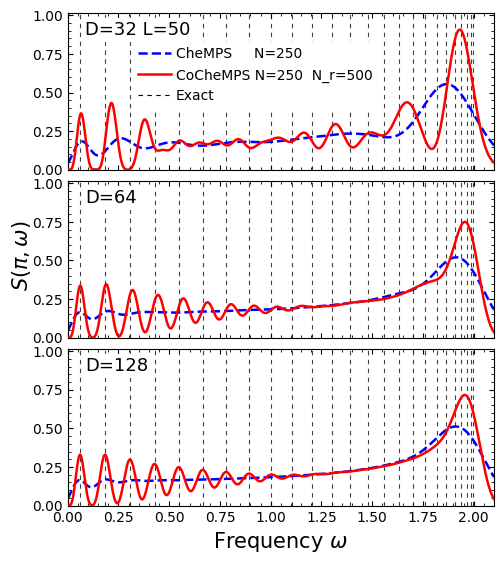

D=32: CheMPS max=0.554646, CoCheMPS max=0.907509
D=64: CheMPS max=0.5204, CoCheMPS max=0.750265
D=128: CheMPS max=0.512289, CoCheMPS max=0.716614


In [17]:
fig, axes = plt.subplots(
    len(BOND_DIMS),
    1,
    figsize=(5.5, 6.4),
    sharex=True,
    gridspec_kw={"hspace": 0.07},
)
if len(BOND_DIMS) == 1:
    axes = [axes]

plot_peak = 0.0
for D in BOND_DIMS:
    result = bond_dim_results[D]
    spectra = [result["vals_ttns"].real]
    if RUN_COCHEBYSHEV and result["vals_ttns_eff"] is not None:
        spectra.append(result["vals_ttns_eff"].real)
    for vals in spectra:
        finite_vals = vals[np.isfinite(vals)]
        if finite_vals.size:
            plot_peak = max(plot_peak, float(np.nanmax(finite_vals)))
y_max = 1.12 * plot_peak if plot_peak > 0.0 else 1.0

for panel_idx, (ax, D) in enumerate(zip(axes, BOND_DIMS)):
    result = bond_dim_results[D]
    for omega in omega_exact:
        if omega <= E_PLOT_MAX:
            ax.axvline(
                omega,
                color="k",
                linestyle=(0, (4, 4)),
                linewidth=0.8,
                alpha=0.75,
                zorder=0,
            )

    ax.plot(
        result["omega_grid"],
        result["vals_ttns"].real,
        color="blue",
        linewidth=1.8,
        linestyle="--",
        label=f"CheMPS     N={CHEB_TTNS_BASIS_SIZE}",
        zorder=2,
    )
    if RUN_COCHEBYSHEV:
        ax.plot(
            result["omega_grid"],
            result["vals_ttns_eff"].real,
            color="red",
            linewidth=1.8,
            label=f"CoCheMPS N={CHEB_TTNS_BASIS_SIZE}  N_r={COCHEB_MAIN_N}",
            zorder=3,
        )

    label = f"D={D}" + (f" L={N_SITES}" if panel_idx == 0 else "")
    ax.text(
        0.04,
        0.86,
        label,
        transform=ax.transAxes,
        fontsize=13,
        bbox={"facecolor": "white", "edgecolor": "white", "boxstyle": "square,pad=0.15", "alpha": 1.0},
        zorder=5,
    )
    ax.set_xlim(0.0, E_PLOT_MAX)
    ax.set_ylim(0.0, y_max)
    ax.tick_params(direction="in", top=True, right=True, which="both")
    ax.minorticks_on()

legend_handles = [
    plt.Line2D([], [], color="blue", linestyle="--", linewidth=1.8, label=f"CheMPS     N={CHEB_TTNS_BASIS_SIZE}"),
    plt.Line2D([], [], color="red", linewidth=1.8, label=f"CoCheMPS N={CHEB_TTNS_BASIS_SIZE}  N_r={COCHEB_MAIN_N}"),
    plt.Line2D([], [], color="k", linestyle=(0, (4, 4)), linewidth=0.8, label="Exact"),
]
axes[0].legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.44, 0.86),
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    facecolor="white",
    edgecolor="white",
    handlelength=2.4,
    handletextpad=0.35,
)

fig.supylabel(r"$S(\pi,\omega)$", x=0.02, fontsize=15)
axes[-1].set_xlabel(r"Frequency $\omega$", fontsize=15)

output_pdf = "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CoChebyshev_1D_XY_Direct_Truncate_BondDim.pdf"
fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Saved figure to {output_pdf}")
plt.show()

for D, result in bond_dim_results.items():
    print(
        f"D={D}: CheMPS max={np.nanmax(result['vals_ttns'].real):.6g}, "
        f"CoCheMPS max={np.nanmax(result['vals_ttns_eff'].real):.6g}"
    )
